# LangGraph 기본 문제: 뉴스 리포트 파이프라인 그래프 설계하기 - 교사용 정답본

이 노트북은 학생용 문제의 정답 코드가 포함된 버전이다.

# LangGraph 기본 문제: 뉴스 리포트 파이프라인 그래프 설계하기

이 노트북의 목표는 **LangGraph의 순차 그래프를 직접 설계할 수 있는지 확인하는 것**이다.

학생은 `검색` 함수와 `리포트작성` 함수의 내부 구현을 수정하지 않는다.  
이미 제공된 노드 함수를 사용해 **StateGraph에 노드를 등록하고 Edge를 연결하는 부분만 완성**한다.

## 완성해야 할 그래프

```mermaid
flowchart TD
    START([START]) --> SEARCH[검색]
    SEARCH --> REPORT[리포트작성]
    REPORT --> END([END])
```

## 학습 목표

1. `StateGraph`를 생성할 수 있다.
2. 노드 함수를 그래프에 등록할 수 있다.
3. `START`에서 첫 번째 노드로 이동하는 Edge를 연결할 수 있다.
4. 노드와 노드를 순차적으로 연결할 수 있다.
5. 마지막 노드에서 `END`로 종료 흐름을 연결할 수 있다.
6. `invoke()`와 `stream()`으로 그래프 실행 결과를 확인할 수 있다.

## 문제 상황

사용자가 입력한 주제에 대해 다음 흐름으로 뉴스 리포트를 생성하는 그래프를 설계한다.

1. `검색` 노드에서 검색 결과를 만든다.
2. `리포트작성` 노드에서 검색 결과를 바탕으로 최종 리포트를 만든다.
3. 리포트 작성이 끝나면 그래프를 종료한다.

## 제공 노드

| 노드 이름 | 역할 | 학생 수정 여부 |
|---|---|---|
| `검색` | 주제에 맞는 검색 결과를 만든다. | 수정하지 않음 |
| `리포트작성` | 검색 결과를 바탕으로 뉴스 리포트를 만든다. | 수정하지 않음 |

## 학생이 완성할 부분

학생은 아래 3가지만 완성한다.

1. `builder.add_node()`로 노드를 등록한다.
2. `builder.add_edge()`로 실행 순서를 연결한다.
3. `builder.compile()`로 그래프를 컴파일한다.

## 평가 기준

| 평가 항목 | 확인 내용 |
|---|---|
| State 이해 | `ReportState`의 필드 역할을 설명할 수 있는가 |
| 노드 등록 | `검색`, `리포트작성` 노드가 모두 등록되었는가 |
| 시작 Edge | `START → 검색` 흐름이 연결되었는가 |
| 순차 Edge | `검색 → 리포트작성` 흐름이 연결되었는가 |
| 종료 Edge | `리포트작성 → END` 흐름이 연결되었는가 |
| 실행 확인 | `invoke()` 실행 후 `report` 값이 생성되는가 |
| 단계 확인 | `stream()`으로 노드별 반환값을 확인할 수 있는가 |

## 1. 기본 설정

In [1]:
# 필요 시 아래 주석을 해제해 설치한다.
# %pip install -U langgraph typing_extensions

from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

## 2. State 정의

In [2]:
class ReportState(TypedDict):
    """뉴스 리포트 파이프라인에서 공유하는 State이다."""

    # 사용자가 입력한 원래 주제이다.
    topic: str

    # 실제 검색에 사용한 검색어이다.
    search_query: str

    # 검색 결과 목록이다.
    search_results: list[dict]

    # 최종 뉴스 리포트이다.
    report: str

## 3. 제공 함수와 제공 노드

In [3]:
def format_search_results(results: list[dict]) -> str:
    """검색 결과를 리포트 작성에 사용할 수 있는 문자열로 변환한다."""

    if not results:
        return "검색 결과가 없다."

    lines = []

    for idx, item in enumerate(results, start=1):
        title = item.get("title", "제목 없음")
        url = item.get("url", "URL 없음")
        content = item.get("content", "내용 없음")

        lines.append(
            f"[{idx}] {title}\n"
            f"URL: {url}\n"
            f"내용: {content}"
        )

    return "\n\n".join(lines)


def show_graph(app) -> None:
    """LangGraph 구조를 시각화한다.

    1차: Mermaid PNG 이미지 출력
    2차: ASCII 그래프 출력
    3차: Mermaid 코드 텍스트 출력
    """

    graph = app.get_graph()

    try:
        display(Image(graph.draw_mermaid_png()))
        return
    except Exception as e:
        print(f"Mermaid PNG 생성 실패: {e}")

    try:
        print(graph.draw_ascii())
        return
    except Exception as e:
        print(f"ASCII 그래프 생성 실패: {e}")

    print("Mermaid 코드로 대체 출력한다.")
    print(graph.draw_mermaid())

In [4]:
def search_node(state: ReportState) -> dict:
    """검색 노드이다.

    실제 Tavily API를 호출하지 않고, 수업용 가짜 검색 결과를 반환한다.
    그래프 설계 실습에서는 외부 API보다 노드 연결 구조가 더 중요하다.
    """

    query = state["topic"]
    print(f"[검색] 검색어: {query}")

    results = [
        {
            "title": f"{query} 관련 기사 1",
            "url": "https://example.com/news-1",
            "content": f"{query}와 관련된 주요 변화와 산업 동향을 설명하는 기사이다."
        },
        {
            "title": f"{query} 관련 기사 2",
            "url": "https://example.com/news-2",
            "content": f"{query}의 교육, 기업 활용, 정책적 쟁점을 다루는 기사이다."
        },
        {
            "title": f"{query} 관련 기사 3",
            "url": "https://example.com/news-3",
            "content": f"{query}가 현장 실무와 학습 방식에 미치는 영향을 정리한 기사이다."
        },
    ]

    return {
        "search_query": query,
        "search_results": results,
    }


def report_node(state: ReportState) -> dict:
    """리포트 작성 노드이다.

    검색 결과를 바탕으로 간단한 뉴스 브리핑을 만든다.
    실제 LLM 호출 대신 문자열 조합 방식으로 처리한다.
    """

    search_text = format_search_results(state["search_results"])

    report = f"""# 뉴스 리포트: {state['topic']}

## 핵심 요약
- 검색어 `{state['search_query']}`를 기준으로 관련 기사 {len(state['search_results'])}건을 확인했다.
- 주요 내용은 산업 동향, 교육 활용, 현장 적용 가능성으로 정리할 수 있다.

## 검색 결과 정리
{search_text}

## 수업 관점 정리
이 그래프는 `검색` 노드와 `리포트작성` 노드를 순차적으로 연결하는 기본 파이프라인 구조이다.
"""

    print("[리포트작성] 리포트 생성 완료")

    return {
        "report": report
    }

## 4. 그래프 구성 문제

아래 `TODO` 부분을 완성한다.

완성해야 할 흐름은 다음과 같다.

```text
START → 검색 → 리포트작성 → END
```

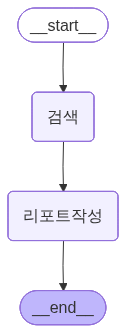

In [5]:
builder = StateGraph(ReportState)

# 노드 등록
builder.add_node("검색", search_node)
builder.add_node("리포트작성", report_node)

# Edge 연결
builder.add_edge(START, "검색")
builder.add_edge("검색", "리포트작성")
builder.add_edge("리포트작성", END)

# 그래프 컴파일
app = builder.compile()

# 그래프 시각화
show_graph(app)

## 5. 그래프 시각화

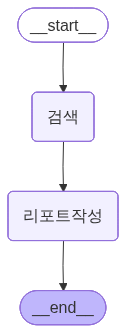

In [6]:
# 완성된 그래프의 Mermaid 코드를 출력한다.
# 환경에 따라 이미지 렌더링은 지원되지 않을 수 있다.
from IPython.display import Image, display

def show_graph(app) -> None:
    """LangGraph 구조를 시각화한다.

    Mermaid PNG 생성이 실패하면 ASCII 그래프로 대체한다.
    """
    try:
        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception as e:
        print(f"Mermaid 이미지 생성 실패: {e}")
        print(app.get_graph().draw_ascii())


show_graph(app)


## 6. 그래프 실행

그래프가 제대로 구성되었다면 아래 코드를 실행했을 때 최종 `report`가 출력된다.

In [7]:
initial_state: ReportState = {
    "topic": "생성형 AI 교육 트렌드",
    "search_query": "",
    "search_results": [],
    "report": "",
}

result = app.invoke(initial_state)

print("=" * 70)
print("최종 리포트")
print("=" * 70)
print(result["report"])

[검색] 검색어: 생성형 AI 교육 트렌드
[리포트작성] 리포트 생성 완료
최종 리포트
# 뉴스 리포트: 생성형 AI 교육 트렌드

## 핵심 요약
- 검색어 `생성형 AI 교육 트렌드`를 기준으로 관련 기사 3건을 확인했다.
- 주요 내용은 산업 동향, 교육 활용, 현장 적용 가능성으로 정리할 수 있다.

## 검색 결과 정리
[1] 생성형 AI 교육 트렌드 관련 기사 1
URL: https://example.com/news-1
내용: 생성형 AI 교육 트렌드와 관련된 주요 변화와 산업 동향을 설명하는 기사이다.

[2] 생성형 AI 교육 트렌드 관련 기사 2
URL: https://example.com/news-2
내용: 생성형 AI 교육 트렌드의 교육, 기업 활용, 정책적 쟁점을 다루는 기사이다.

[3] 생성형 AI 교육 트렌드 관련 기사 3
URL: https://example.com/news-3
내용: 생성형 AI 교육 트렌드가 현장 실무와 학습 방식에 미치는 영향을 정리한 기사이다.

## 수업 관점 정리
이 그래프는 `검색` 노드와 `리포트작성` 노드를 순차적으로 연결하는 기본 파이프라인 구조이다.



## 7. stream으로 단계별 실행 확인

`stream_mode="updates"`를 사용하면 각 노드가 반환한 값을 단계별로 확인할 수 있다.

In [8]:
for event in app.stream(
    {
        "topic": "AI 에이전트 최신 동향",
        "search_query": "",
        "search_results": [],
        "report": "",
    },
    stream_mode="updates",
):
    print(event)

[검색] 검색어: AI 에이전트 최신 동향
{'검색': {'search_query': 'AI 에이전트 최신 동향', 'search_results': [{'title': 'AI 에이전트 최신 동향 관련 기사 1', 'url': 'https://example.com/news-1', 'content': 'AI 에이전트 최신 동향와 관련된 주요 변화와 산업 동향을 설명하는 기사이다.'}, {'title': 'AI 에이전트 최신 동향 관련 기사 2', 'url': 'https://example.com/news-2', 'content': 'AI 에이전트 최신 동향의 교육, 기업 활용, 정책적 쟁점을 다루는 기사이다.'}, {'title': 'AI 에이전트 최신 동향 관련 기사 3', 'url': 'https://example.com/news-3', 'content': 'AI 에이전트 최신 동향가 현장 실무와 학습 방식에 미치는 영향을 정리한 기사이다.'}]}}
[리포트작성] 리포트 생성 완료
{'리포트작성': {'report': '# 뉴스 리포트: AI 에이전트 최신 동향\n\n## 핵심 요약\n- 검색어 `AI 에이전트 최신 동향`를 기준으로 관련 기사 3건을 확인했다.\n- 주요 내용은 산업 동향, 교육 활용, 현장 적용 가능성으로 정리할 수 있다.\n\n## 검색 결과 정리\n[1] AI 에이전트 최신 동향 관련 기사 1\nURL: https://example.com/news-1\n내용: AI 에이전트 최신 동향와 관련된 주요 변화와 산업 동향을 설명하는 기사이다.\n\n[2] AI 에이전트 최신 동향 관련 기사 2\nURL: https://example.com/news-2\n내용: AI 에이전트 최신 동향의 교육, 기업 활용, 정책적 쟁점을 다루는 기사이다.\n\n[3] AI 에이전트 최신 동향 관련 기사 3\nURL: https://example.com/news-3\n내용: AI 에이전트 최신 동향가 현장 실무와 학습 방식에 미치는 영향을 정리한 기사이다.\n\

## 7. 점검 질문

아래 질문에 답할 수 있으면 이 문제의 목표를 달성한 것이다.

1. 왜 `START`는 `검색` 노드와 연결되어야 하는가?
2. `검색` 노드가 반환한 `search_results`는 어느 노드에서 사용되는가?
3. `리포트작성` 노드 뒤에 `END`를 연결하지 않으면 어떤 문제가 생길 수 있는가?
4. 이 그래프는 조건부 분기가 있는 그래프인가, 순차 파이프라인 그래프인가?
5. 다음 단계에서 검색 결과가 부족할 때 다시 검색하게 하려면 어떤 노드와 Edge가 추가되어야 하는가?

## 교사용 운영 메모

이 문제는 조건부 분기 이전 단계의 가장 단순한 LangGraph 파이프라인 설계 문제이다.

수업에서는 다음 순서로 설명하면 좋다.

1. `State`는 노드 사이에서 공유되는 데이터 구조이다.
2. `검색` 노드는 `search_query`, `search_results`를 갱신한다.
3. `리포트작성` 노드는 `search_results`를 읽고 `report`를 갱신한다.
4. `add_node()`는 작업 단위를 그래프에 등록하는 코드이다.
5. `add_edge()`는 실행 순서를 정의하는 코드이다.
6. 이 예제는 `START → 검색 → 리포트작성 → END`라는 선형 파이프라인이다.

학생들이 이 문제를 해결한 뒤, 다음 단계에서 `요약`, `검증`, `검색어재작성`, 조건부 Edge를 추가하면 자연스럽게 재검색 루프 그래프로 확장할 수 있다.